<a href="https://colab.research.google.com/github/mduchin/ohio-precincts/blob/master/future/evictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/PUBPOL-2130/notebooks/blob/main/future/evictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%config InlineBackend.figure_formats = ["retina"]

In [2]:
!pip install -q folium scikit-learn census seaborn geopandas us

In [3]:
!curl -OL https://raw.githubusercontent.com/PUBPOL-2130/notebooks/main/data/mappluto_subset.gpkg.zip
!unzip mappluto_subset.gpkg.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 13.0M  100 13.0M    0     0  11.3M      0  0:00:01  0:00:01 --:--:-- 11.3M
Archive:  mappluto_subset.gpkg.zip
  inflating: mappluto_subset.gpkg    
  inflating: __MACOSX/._mappluto_subset.gpkg  


## Evictions

In [4]:
import census
import folium
import folium.plugins
import geopandas as gpd
import io
import us
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from census import Census
from shapely import Point

In [5]:
census = Census("", year=2018)

We'll start this week with data from the [Eviction Lab](https://evictionlab.org/) at Princeton, home of Matt Desmond and this week's guest Peter Hepburn. This data has been assembled and compiled from multiple sources, and more information on the methods they've used can be found [here](https://evictionlab.org/methods/). It is a powerful resource for studying eviction patterns throughout the United States.

To get a sense of what this data looks like interactively, you can explore their [interactive map](https://evictionlab.org/map).

We'll start with data for estimating eviction prevalence.  Each row is a county in a particular year, from 2000 to 2018.

In [6]:
df_eviction_prev = pd.read_csv(
    "https://eviction-lab-data-downloads.s3.amazonaws.com/estimating-eviction-prevalance-across-us/county_eviction_estimates_2000_2018.csv"
)
df_eviction_prev.head()

,state,county,FIPS_state,FIPS_county,year,renting_hh,filings_estimate,filings_ci_95_lower,filings_ci_95_upper,ind_filings_court_issued,ind_filings_court_issued_LT,hh_threat_estimate,hh_threat_95_lower,hh_threat_95_upper,ind_hht_observed
0,Alabama,Autauga County,1,1001,2000,3074,109,109,109,1,0.0,106,106,106,1
1,Alabama,Autauga County,1,1001,2001,3264,75,75,75,1,0.0,74,71,75,0
2,Alabama,Autauga County,1,1001,2002,3454,94,94,94,1,0.0,92,88,94,0
3,Alabama,Autauga County,1,1001,2003,3644,100,100,100,1,0.0,98,94,100,0
4,Alabama,Autauga County,1,1001,2004,3834,112,112,112,1,0.0,110,106,112,0


Next we'll calculate three measures that are common in the eviction literature and that the Eviction Lab reports.  These are a little confusing, so read carefully!

* *Eviction filing rate:* the total number of evictions *filed* per 100 renter-occupied homes in that area for a given year.  Note that this can reflect many filings on one apartment.
* *Households threatened rate:* the total number of renter-occupied households who ever received an eviction filing in a given year, per 100.
* *Eviction rate:* the number of renters who received an eviction judgment/court order requiring them to leave over all renter-occupied homes in a given year.

So suppose there were 100 apartments in all, and 3 of them were filed on 5 times each, and out of those three, two resulted in a court order.  Then the filing rate would be 15, the threatened rate would be 3, and the eviction rate would be 2.  So these numbers should be ordered from largest to smallest.

Also notable:  they give two options for what dataset to use, which they call "Modeled" vs. "Original."  The "original" data comes from proprietary sources -- that means they largely bought it, and it's hard to vouch for the quality.  The "modeled" version uses official court data and smooths it out with some statistical tools.

Filing rate and threatened rate are both available from the modeled data.  Let's look at those first.

In [7]:
df_eviction_prev["filing_rate"] = (
    df_eviction_prev["filings_estimate"] * 100 / df_eviction_prev["renting_hh"]
)
df_eviction_prev["threatened_rate"] = (
    df_eviction_prev["hh_threat_estimate"] * 100 / df_eviction_prev["renting_hh"]
)

In [8]:
df_eviction_prev[["filing_rate", "threatened_rate"]].describe()

,filing_rate,threatened_rate
count,59717.000000,59717.000000
mean,5.010749,4.174013
std,7.472987,4.620251
min,0.000000,0.000000
25%,1.381999,1.351351
50%,2.810651,2.698651
75%,5.657193,5.190311
max,154.618193,59.569671


So there was some county that had a filing rate over 150 filings per 100 units -- more than one filing per housing unit! -- in a certain year.

In [9]:
df_eviction_prev_avg = df_eviction_prev.groupby("FIPS_county")[
    ["filing_rate", "threatened_rate"]
].mean()
df_eviction_prev_avg.head()

,filing_rate,threatened_rate
FIPS_county,,
1001,2.870842,2.815528
1003,3.258419,3.167612
1005,0.888459,0.888459
1007,1.460639,1.455666
1009,1.524526,1.505942


In [ ]:
# load counties shapefiles to map
gdf_counties = gpd.read_file(
    "https://raw.githubusercontent.com/PUBPOL-2130/notebooks/main/data/tl_2018_us_county.zip"
).to_crs(2163)
gdf_counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,None,None,None,A,1477652222,10690952,+41.9158651,-096.7885168,"POLYGON ((246290.041 -328619.667, 246286.51 -3..."
1,53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,None,None,A,680956809,61588406,+46.2946377,-123.4244583,"POLYGON ((-1770686.984 398793.664, -1771124.91..."
2,35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,None,None,None,A,6016819484,29089486,+34.3592729,-104.3686961,"POLYGON ((-422754.447 -1210188.449, -422784.93..."
3,31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,None,A,2169287528,22832516,+40.7835474,-096.6886584,"POLYGON ((260193.977 -463717.021, 260172 -4631..."
4,31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,None,None,None,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((146978.459 -544334.301, 146978.432 -..."


In [ ]:
gdf_counties["county_fips_full"] = (
    gdf_counties["STATEFP"] + gdf_counties["COUNTYFP"]
).astype(int)
gdf_counties.set_index("county_fips_full", inplace=True)

In [ ]:
gdf_eviction_filings_avg = gdf_counties[
    ["STATEFP", "COUNTYFP", "NAME", "NAMELSAD", "geometry"]
].join(df_eviction_prev_avg, how="left")

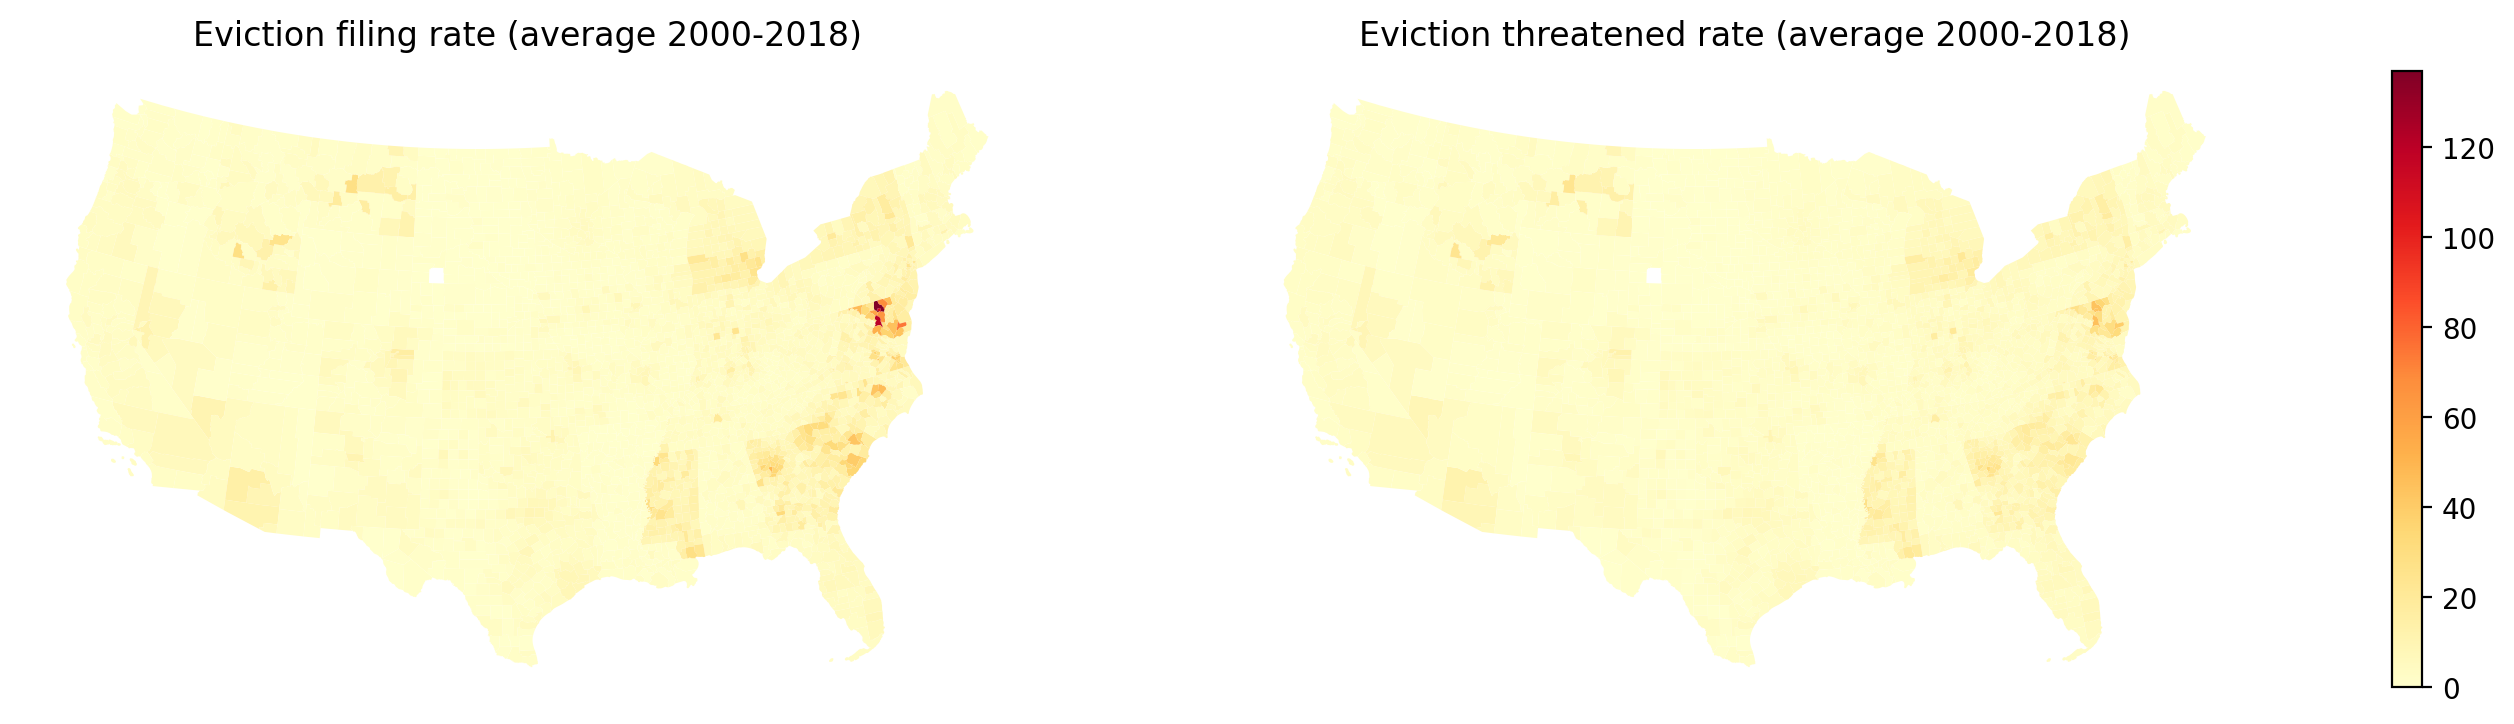

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# filter out hawaii and alaska for visualization
state_filter = ~gdf_eviction_filings_avg.STATEFP.isin(["15", "02"])
gdf_eviction_filings_avg[state_filter].plot(
    column="filing_rate", ax=axes[0], vmin=0, vmax=137, cmap="YlOrRd", legend=False
)
gdf_eviction_filings_avg[state_filter].plot(
    column="threatened_rate", ax=axes[1], vmin=0, vmax=137, cmap="YlOrRd", legend=False
)
axes[0].set_title("Eviction filing rate (average 2000-2018)")
axes[1].set_title("Eviction threatened rate (average 2000-2018)")
axes[0].set_axis_off()
axes[1].set_axis_off()

# assume it's the first (and only) mappable
patch_col = axes[0].collections[0]
cb = fig.colorbar(patch_col, ax=axes, shrink=0.5)

What area had the highest filing rate (and is colored in a dark red in the mid-Atlantic region)?

In [ ]:
gdf_eviction_filings_avg[
    gdf_eviction_filings_avg["filing_rate"]
    == gdf_eviction_filings_avg["filing_rate"].max()
]

,STATEFP,COUNTYFP,NAME,NAMELSAD,geometry,filing_rate,threatened_rate
county_fips_full,,,,,,,
24005,24,005,Baltimore,Baltimore County,"POLYGON ((1955260.174 -342141.577, 1955257.421...",136.00706,43.924319


We can also look at some of the counties with eviction filing rates > 99th percentile.

In [ ]:
gdf_eviction_filings_avg[
    gdf_eviction_filings_avg["filing_rate"]
    >= gdf_eviction_filings_avg["filing_rate"].quantile(0.99)
].sort_values("filing_rate", ascending=False)

,STATEFP,COUNTYFP,NAME,NAMELSAD,geometry,filing_rate,threatened_rate
county_fips_full,,,,,,,
24005,24,005,Baltimore,Baltimore County,"POLYGON ((1955260.174 -342141.577, 1955257.421...",136.007060,43.924319
24033,24,033,Prince George's,Prince George's County,"POLYGON ((1964183.368 -398913.172, 1964168.607...",120.083112,45.318629
24510,24,510,Baltimore,Baltimore city,"POLYGON ((1971826.798 -345975.085, 1971825.144...",110.622484,43.850641
24045,24,045,Wicomico,Wicomico County,"POLYGON ((2072705.275 -430164.685, 2072319.122...",74.652782,39.320539
24025,24,025,Harford,Harford County,"POLYGON ((1988265.098 -324652.901, 1988253.165...",68.281529,35.009560
24003,24,003,Anne Arundel,Anne Arundel County,"POLYGON ((1970416.791 -374960.982, 1970424.931...",64.296728,29.491537
24027,24,027,Howard,Howard County,"POLYGON ((1948661.073 -368116.611, 1948639.104...",57.550384,25.251823
24017,24,017,Charles,Charles County,"POLYGON ((1950169.833 -445836.699, 1950169.069...",51.958124,28.840489
13063,13,063,Clayton,Clayton County,"POLYGON ((1436807.483 -1134446.214, 1436784.17...",48.182131,34.510190


And we can compute the difference in filing and threatened rates difference between 2018 and 2000, to find out what counties experienced the greatest change in their filing rates over time.

In [ ]:
df_eviction_prev.set_index("FIPS_county", inplace=True)
df_eviction_prev_wide = df_eviction_prev[
    df_eviction_prev["year"].isin([2000, 2018])
].pivot(columns="year", values=["threatened_rate", "filing_rate"])
df_eviction_prev_wide.columns = [
    a[0] + "_" + str(a[1]) for a in df_eviction_prev_wide.columns.to_flat_index()
]
df_eviction_prev_wide["filing_rate_diff"] = (
    df_eviction_prev_wide["filing_rate_2018"]
    - df_eviction_prev_wide["filing_rate_2000"]
)
df_eviction_prev_wide["threatened_rate_diff"] = (
    df_eviction_prev_wide["threatened_rate_2018"]
    - df_eviction_prev_wide["threatened_rate_2000"]
)

gdf_eviction_filings_diff = gdf_counties.join(df_eviction_prev_wide)
gdf_eviction_filings_diff.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,...,AWATER,INTPTLAT,INTPTLON,geometry,threatened_rate_2000,threatened_rate_2018,filing_rate_2000,filing_rate_2018,filing_rate_diff,threatened_rate_diff
county_fips_full,,,,,,,,,,,,,,,,,,,,,
31039,31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,None,...,10690952,+41.9158651,-096.7885168,"POLYGON ((246290.041 -328619.667, 246286.51 -3...",0.177148,0.424448,0.177148,0.424448,0.247300,0.247300
53069,53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,None,...,61588406,+46.2946377,-123.4244583,"POLYGON ((-1770686.984 398793.664, -1771124.91...",0.949367,1.818182,1.265823,1.818182,0.552359,0.868815
35011,35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,None,...,29089486,+34.3592729,-104.3686961,"POLYGON ((-422754.447 -1210188.449, -422784.93...",1.477833,2.429150,1.477833,2.429150,0.951317,0.951317
31109,31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,339,...,22832516,+40.7835474,-096.6886584,"POLYGON ((260193.977 -463717.021, 260172 -4631...",3.260454,3.390461,3.495165,3.643536,0.148371,0.130008
31129,31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,None,...,1718484,+40.1764918,-098.0468422,"POLYGON ((146978.459 -544334.301, 146978.432 -...",0.000000,0.179856,0.000000,0.179856,0.179856,0.179856


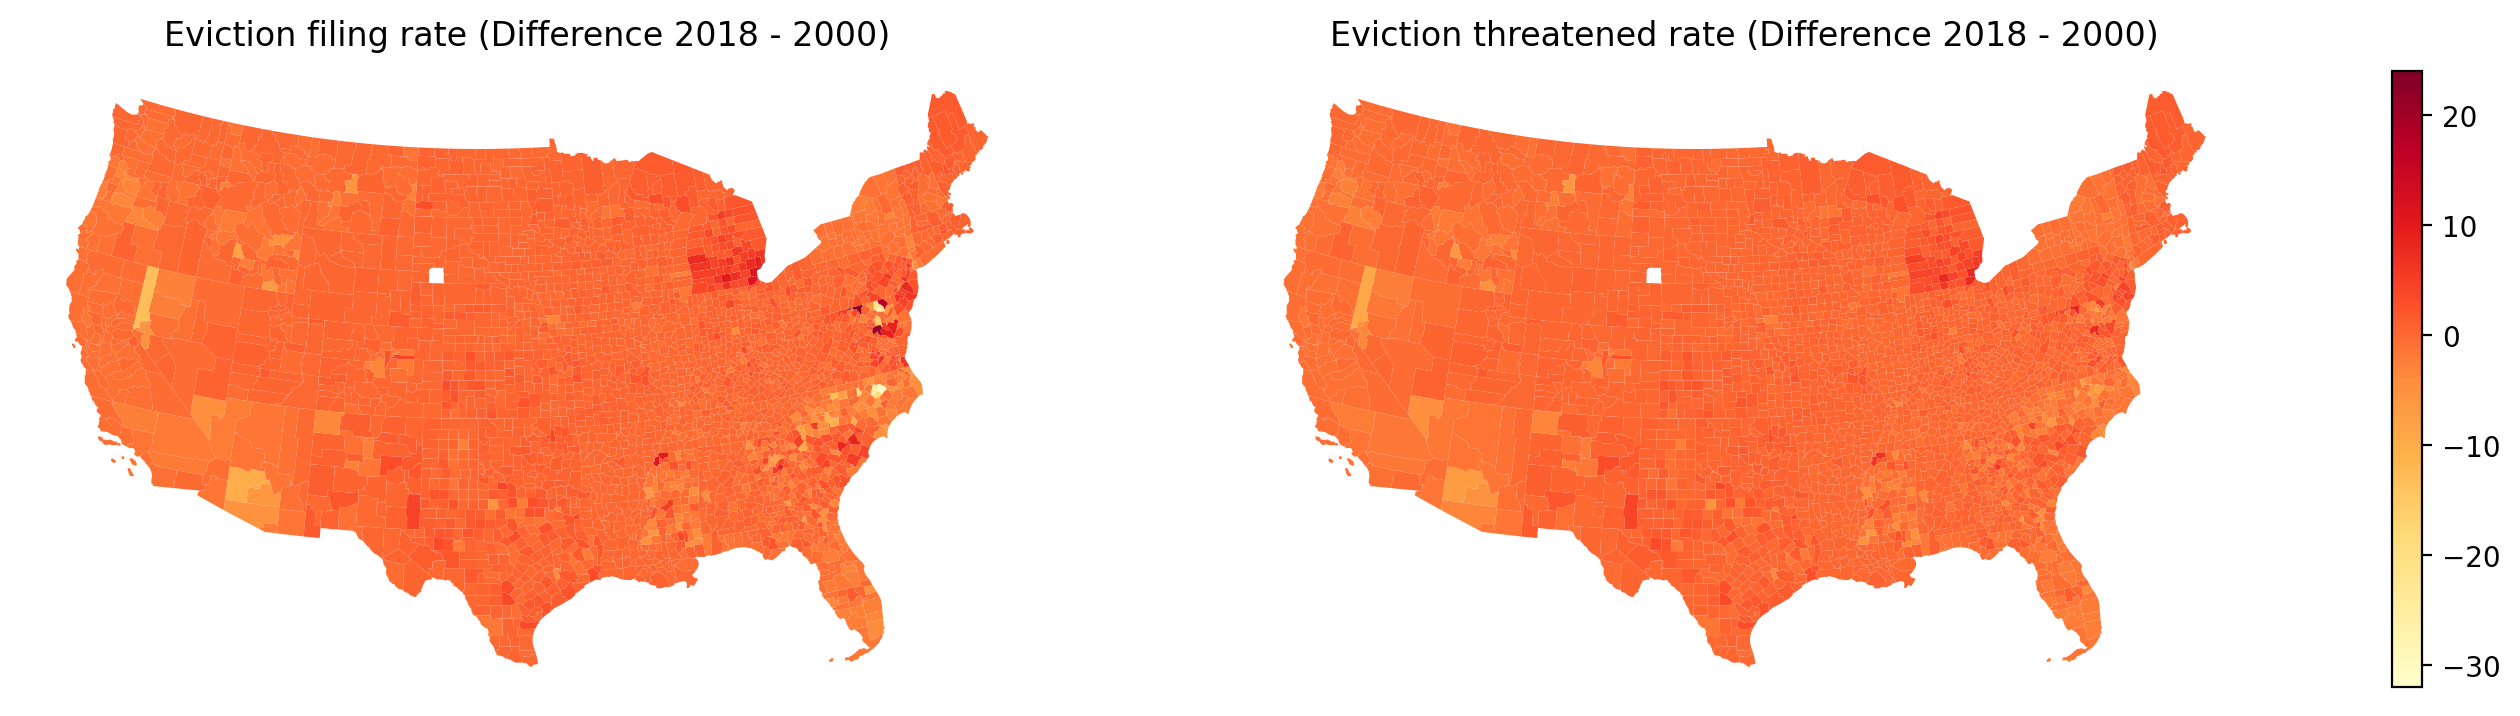

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
# filter out hawaii and alaska for visualization
state_filter = ~gdf_eviction_filings_diff.STATEFP.isin(["15", "02"])
gdf_eviction_filings_diff[state_filter].plot(
    column="filing_rate_diff",
    ax=axes[0],
    vmin=-32,
    vmax=24,
    cmap="YlOrRd",
    legend=False,
)
gdf_eviction_filings_diff[state_filter].plot(
    column="threatened_rate_diff",
    ax=axes[1],
    vmin=-32,
    vmax=24,
    cmap="YlOrRd",
    legend=False,
)
axes[0].set_title("Eviction filing rate (Difference 2018 - 2000)")
axes[1].set_title("Eviction threatened rate (Difference 2018 - 2000)")
axes[0].set_axis_off()
axes[1].set_axis_off()

# assume it's the first (and only) mappable
patch_col = axes[0].collections[0]
cb = fig.colorbar(patch_col, ax=axes, shrink=0.5)

Now we'll explore the proprietary data. The Eviction Lab shares this data on their map, but notes that it has limited coverage and there may be data quality issues. Additionally, these rates have already been produced without denominators, so we won't have to create them ourselves.

In [ ]:
df_proprietary = pd.read_csv(
    "https://eviction-lab-data-downloads.s3.amazonaws.com/estimating-eviction-prevalance-across-us/county_proprietary_2000_2018.csv"
)
df_proprietary.head()

,id,name,parent_location,year,type,filings,filing_rate,threatened,threatened_rate,judgements,judgement_rate
0,1001,Autauga County,Alabama,2000,observed,57.0,1.85,54.0,1.76,35.0,1.14
1,1001,Autauga County,Alabama,2001,observed,84.0,2.73,83.0,2.70,35.0,1.14
2,1001,Autauga County,Alabama,2002,observed,100.0,3.25,97.0,3.16,20.0,0.65
3,1001,Autauga County,Alabama,2003,observed,102.0,3.32,90.0,2.93,12.0,0.39
4,1001,Autauga County,Alabama,2004,observed,19.0,0.62,19.0,0.62,12.0,0.39


In [ ]:
df_proprietary_avg = df_proprietary.groupby(["id"])[
    ["filing_rate", "threatened_rate", "judgement_rate"]
].mean()
df_proprietary_avg.head()

,filing_rate,threatened_rate,judgement_rate
id,,,
1001,2.351053,2.228421,1.226316
1003,3.085789,2.992632,1.646842
1005,0.781053,0.770000,0.416316
1007,0.995789,0.979474,0.537895
1009,1.448947,1.424737,1.033158


In [ ]:
gdf_proprietary_filings = gdf_counties.join(df_proprietary_avg, how="left")

In [ ]:
gdf_proprietary_filings.columns

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry', 'filing_rate',
       'threatened_rate', 'judgement_rate'],
      dtype='object')

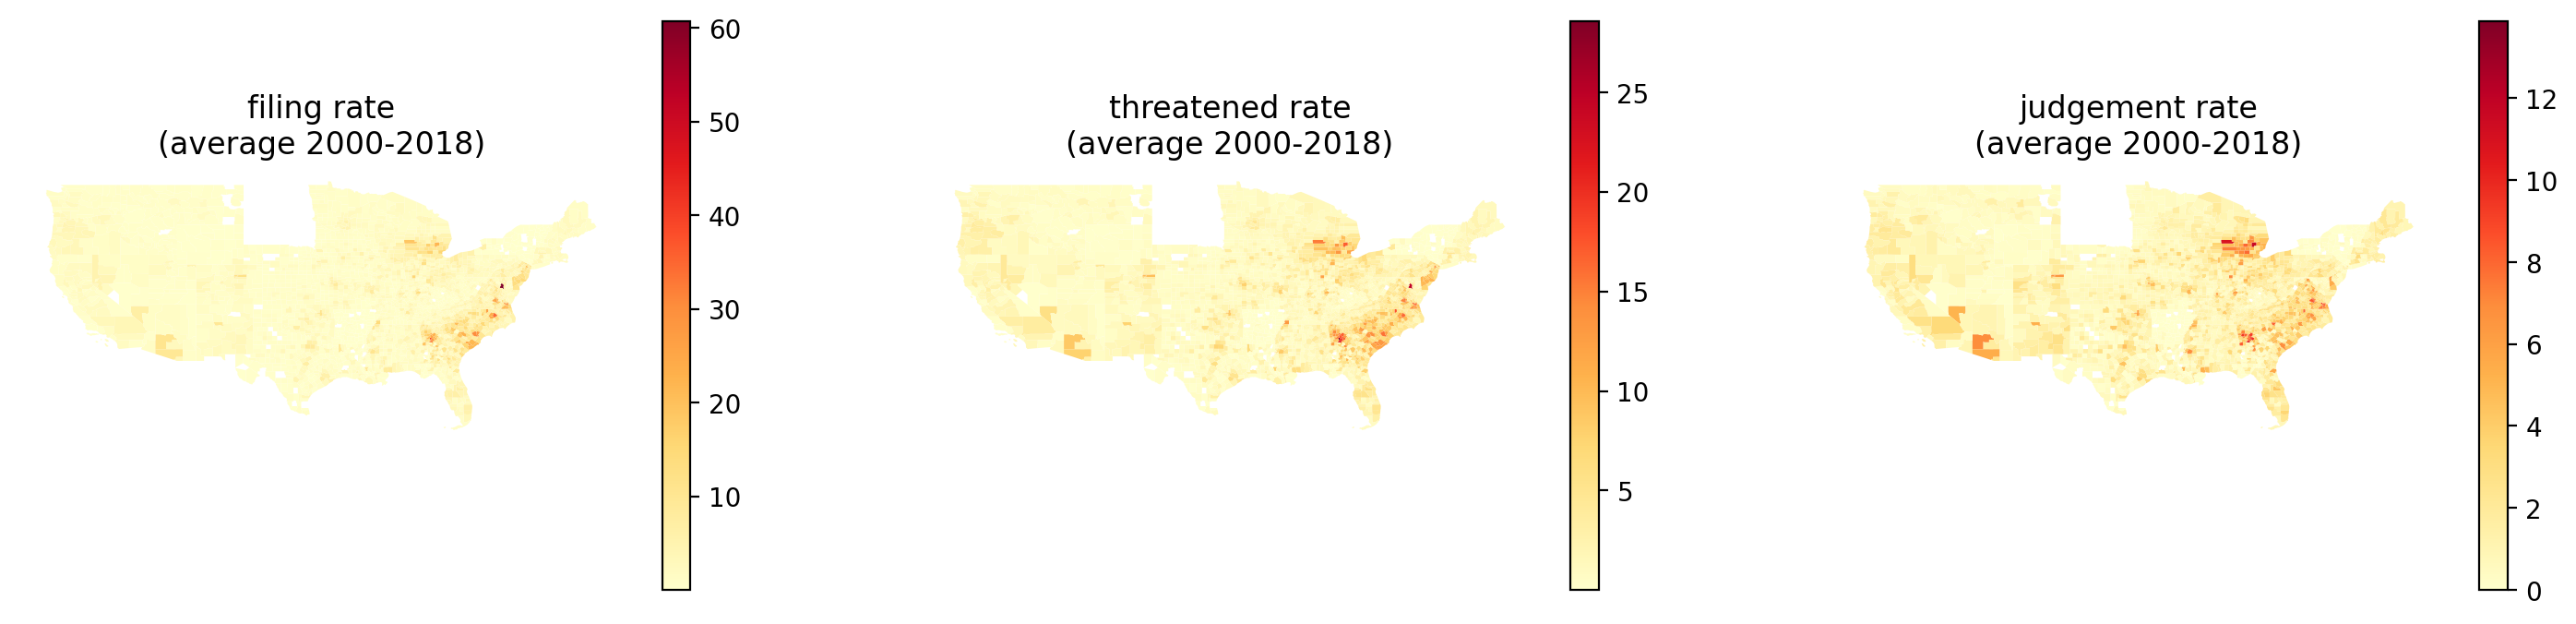

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
# filter out hawaii and alaska for visualization
for i, col in enumerate(["filing_rate", "threatened_rate", "judgement_rate"]):
    state_filter = ~gdf_proprietary_filings.STATEFP.isin(["15", "02"])
    gdf_proprietary_filings[state_filter].plot(
        column=col,
        ax=axes[i],
        cmap="YlOrRd",
        legend=True,
        legend_kwds={"shrink": 0.5},
    )

    axes[i].set_title(f"{col.replace('_',' ')}\n(average 2000-2018)")
    axes[i].set_axis_off()

Interesting, all of the data for North Dakota is not available!

Let's try comparing the modeled data to the proprietary data. It looks like the proprietary data might be undercounting the eviction filing rates and threatened rates.

In [ ]:
df_eviction_mgd = df_eviction_prev.reset_index().merge(
    df_proprietary,
    left_on=["FIPS_county", "year"],
    right_on=["id", "year"],
    suffixes=["_modeled", "_proprietary"],
)

For example, what's happening in Baltimore county?

In [ ]:
df_eviction_mgd[df_eviction_mgd["FIPS_county"] == 24005][
    ["year", "filing_rate_modeled", "filing_rate_proprietary"]
]

,year,filing_rate_modeled,filing_rate_proprietary
22724,2000,121.373512,0.03
22725,2001,118.785111,0.19
22726,2002,125.663771,0.02
22727,2003,122.091880,0.02
22728,2004,123.634952,0.04
22729,2005,125.206232,0.35
22730,2006,131.876556,0.63
22731,2007,140.623602,2.02
22732,2008,141.270577,71.71
22733,2009,154.618193,21.37


In [ ]:
df_eviction_mgd[df_eviction_mgd["FIPS_county"] == 24005][
    ["year", "threatened_rate_modeled", "threatened_rate_proprietary"]
]

,year,threatened_rate_modeled,threatened_rate_proprietary
22724,2000,39.097412,0.03
22725,2001,36.800465,0.18
22726,2002,39.235539,0.02
22727,2003,39.196403,0.02
22728,2004,43.462503,0.04
22729,2005,46.355005,0.33
22730,2006,47.269768,0.58
22731,2007,46.493822,1.97
22732,2008,46.983345,22.98
22733,2009,47.646106,10.58


This is a **huge** undercount!

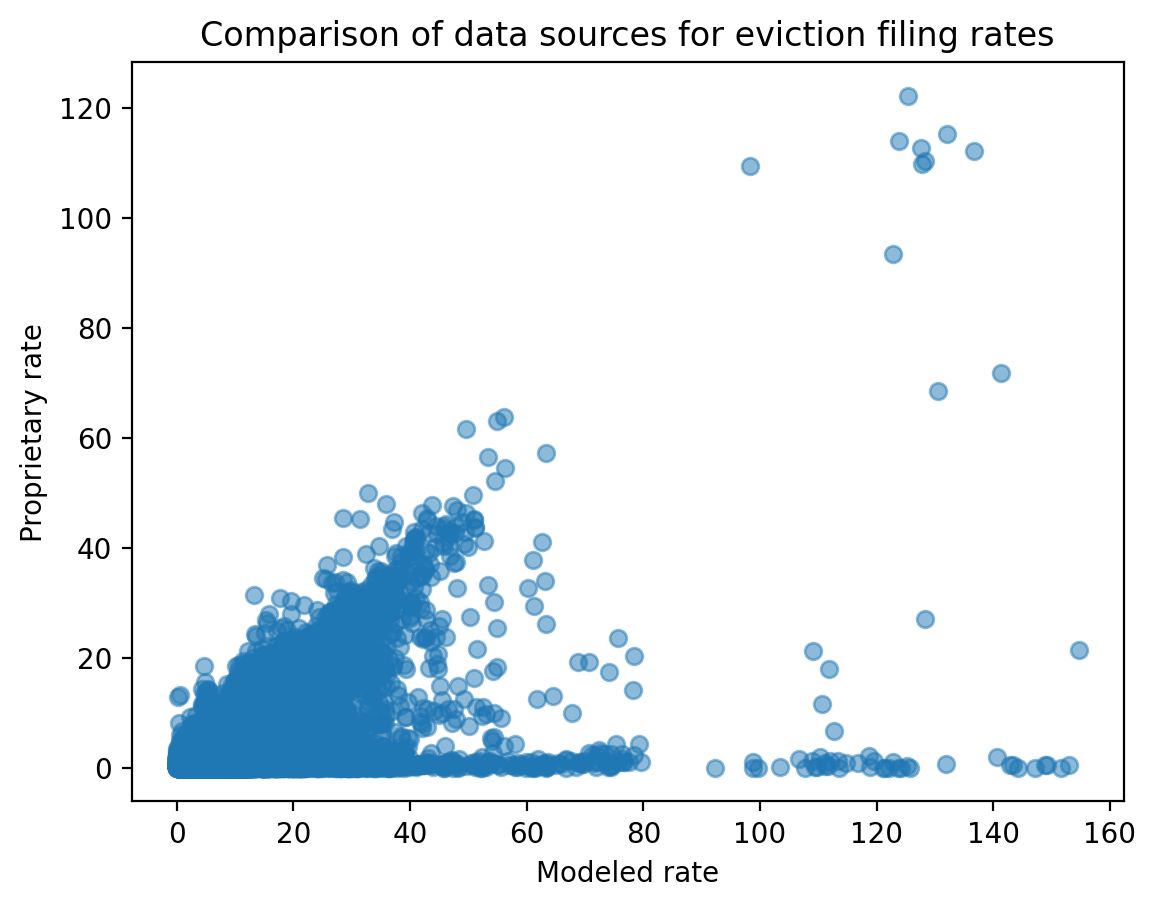

In [ ]:
plt.scatter(
    df_eviction_mgd["filing_rate_modeled"],
    df_eviction_mgd["filing_rate_proprietary"],
    alpha=0.5,
)
plt.xlabel("Modeled rate")
plt.ylabel("Proprietary rate")
plt.title("Comparison of data sources for eviction filing rates")
plt.show()

## Comparison to Census Data

Let's load some county level ACS data.

In [ ]:
acs_cols = [
    "B02001_001E",
    "B02001_002E",
    "B02001_003E",
    "B02001_004E",
    "B02001_005E",
    "B02001_006E",
    "B02001_007E",
    "B02001_008E",
    "B03002_012E",
    "B25038_001E",
    "B25038_009E",
    "B25031_001E",
]
acs_colnames = [
    "totalpop",
    "white",
    "black",
    "aian",
    "asian",
    "nhpi",
    "other",
    "multi",
    "hispanic_latino",
    "totalhh",
    "renters",
    "median_gross_rent",
]

In [ ]:
county_acs_df = pd.DataFrame(
    census.acs5.get(
        tuple(acs_cols),
        geo={
            "for": "county:*",
            "in": "state:*",
        },
        year=2018,
    )
)

In [ ]:
county_acs_df_clean = county_acs_df.rename(
    columns={x: y for x, y in zip(acs_cols, acs_colnames)}
)
county_acs_df_clean["GEOID10"] = (
    county_acs_df_clean["state"] + county_acs_df_clean["county"]
).astype(int)
county_acs_df_clean.set_index("GEOID10", inplace=True)
county_acs_df_clean.head()

,totalpop,white,black,aian,asian,nhpi,other,multi,hispanic_latino,totalhh,renters,median_gross_rent,state,county
GEOID10,,,,,,,,,,,,,,
30061,4211.0,3926.0,3.0,107.0,61.0,0.0,7.0,107.0,81.0,1699.0,459.0,587.0,30,061
30069,432.0,424.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,187.0,61.0,475.0,30,069
30077,6861.0,6235.0,24.0,301.0,34.0,0.0,12.0,255.0,130.0,2388.0,754.0,623.0,30,077
30089,11521.0,10630.0,19.0,410.0,59.0,1.0,23.0,379.0,327.0,4953.0,1162.0,635.0,30,089
30109,1175.0,1167.0,0.0,4.0,4.0,0.0,0.0,0.0,49.0,497.0,106.0,697.0,30,109


In [ ]:
county_acs_df_clean["renters_pct"] = (
    100 * county_acs_df_clean["renters"] / county_acs_df_clean["totalhh"]
)

race_eth_cols = [
    "white",
    "black",
    "aian",
    "asian",
    "nhpi",
    "other",
    "multi",
    "hispanic_latino",
]
for col in race_eth_cols:
    county_acs_df_clean[col + "_pct"] = (
        100 * county_acs_df_clean[col] / county_acs_df_clean["totalpop"]
    )

Let's merge on the Census ACS data.

In [ ]:
county_acs_df_clean

,totalpop,white,black,aian,asian,nhpi,other,multi,hispanic_latino,totalhh,...,county,renters_pct,white_pct,black_pct,aian_pct,asian_pct,nhpi_pct,other_pct,multi_pct,hispanic_latino_pct
GEOID10,,,,,,,,,,,,,,,,,,,,,
30061,4211.0,3926.0,3.0,107.0,61.0,0.0,7.0,107.0,81.0,1699.0,...,061,27.015892,93.232011,0.071242,2.540964,1.448587,0.000000,0.166231,2.540964,1.923534
30069,432.0,424.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,187.0,...,069,32.620321,98.148148,0.000000,0.000000,1.851852,0.000000,0.000000,0.000000,0.000000
30077,6861.0,6235.0,24.0,301.0,34.0,0.0,12.0,255.0,130.0,2388.0,...,077,31.574539,90.875966,0.349803,4.387116,0.495555,0.000000,0.174902,3.716659,1.894768
30089,11521.0,10630.0,19.0,410.0,59.0,1.0,23.0,379.0,327.0,4953.0,...,089,23.460529,92.266296,0.164916,3.558719,0.512108,0.008680,0.199635,3.289645,2.838295
30109,1175.0,1167.0,0.0,4.0,4.0,0.0,0.0,0.0,49.0,497.0,...,109,21.327968,99.319149,0.000000,0.340426,0.340426,0.000000,0.000000,0.000000,4.170213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55049,23620.0,22817.0,194.0,54.0,166.0,19.0,154.0,216.0,411.0,9835.0,...,049,26.273513,96.600339,0.821338,0.228620,0.702794,0.080440,0.651990,0.914479,1.740051
55089,88284.0,82714.0,1200.0,237.0,1970.0,67.0,580.0,1516.0,2526.0,35625.0,...,089,24.232982,93.690816,1.359250,0.268452,2.231435,0.075891,0.656971,1.717185,2.861221
55097,70599.0,65756.0,512.0,262.0,1999.0,11.0,971.0,1088.0,2224.0,28357.0,...,097,31.096378,93.140129,0.725223,0.371110,2.831485,0.015581,1.375374,1.541098,3.150186


In [ ]:
gdf_eviction_filings_demo = gdf_eviction_filings_avg.join(county_acs_df_clean)

# let's also set sentinel values for median gross rent
gdf_eviction_filings_demo["median_gross_rent"] = np.where(
    gdf_eviction_filings_demo["median_gross_rent"] < 0,
    np.nan,
    gdf_eviction_filings_demo["median_gross_rent"],
)

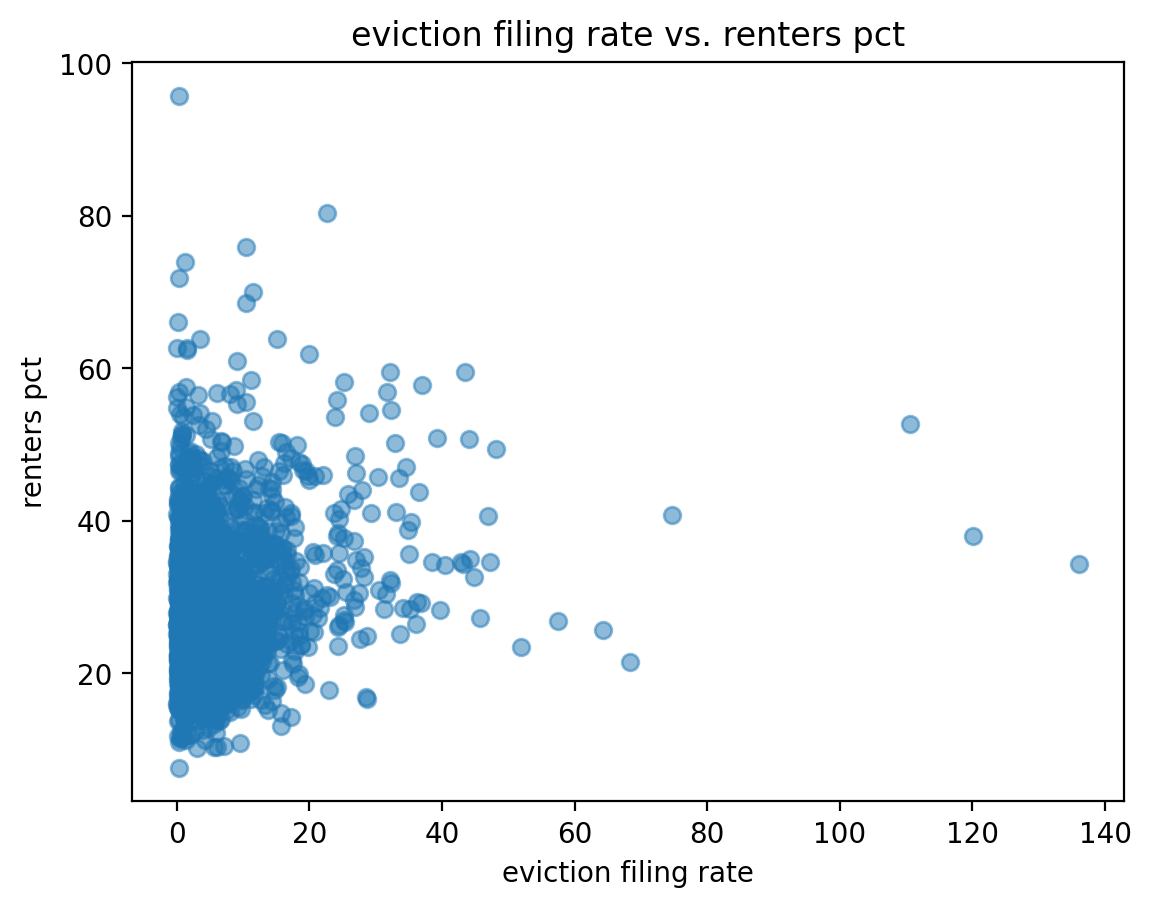

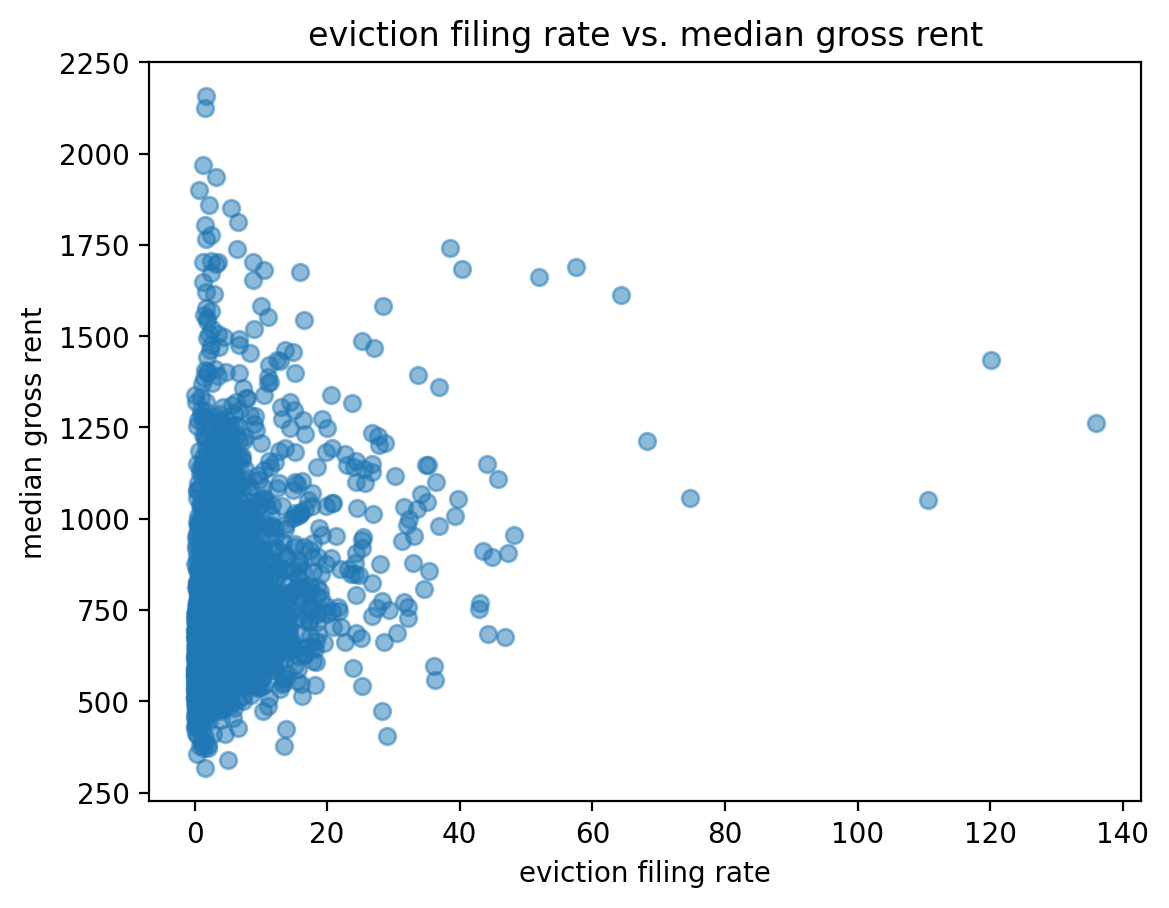

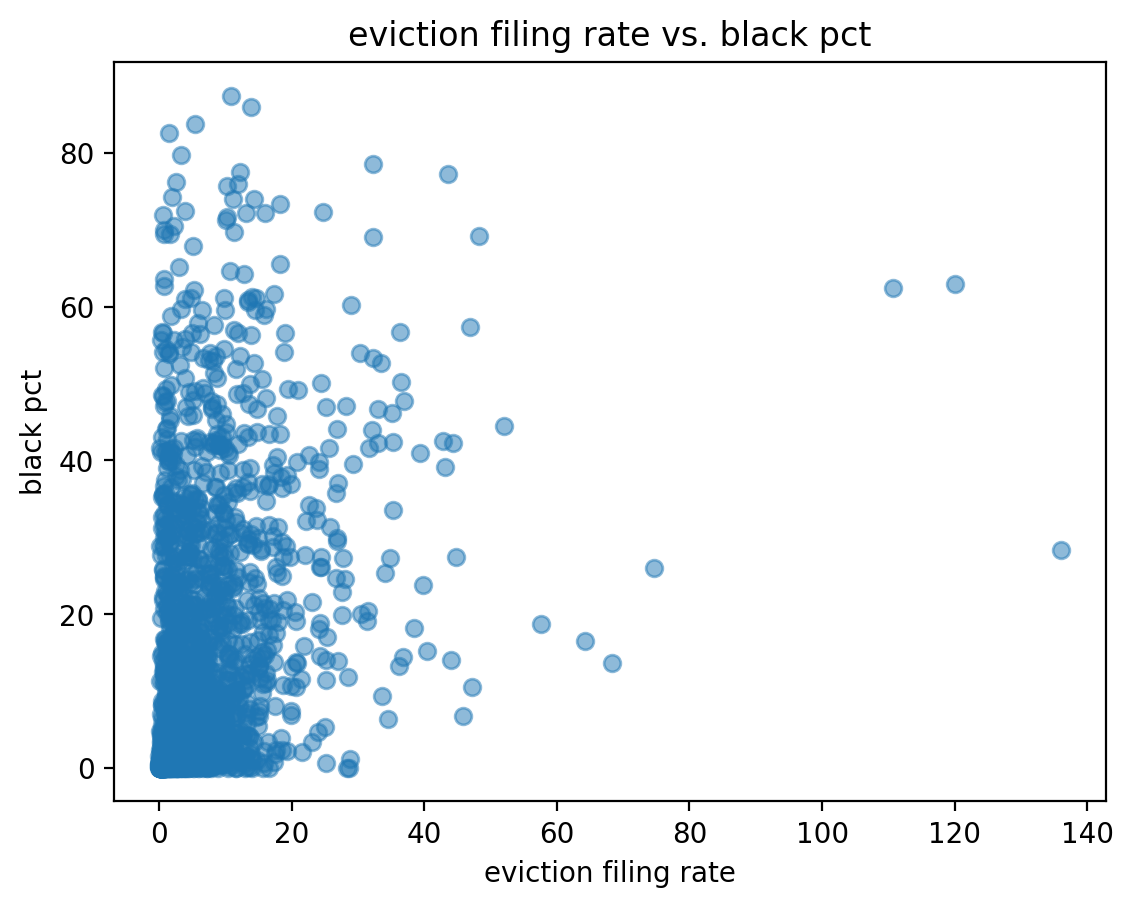

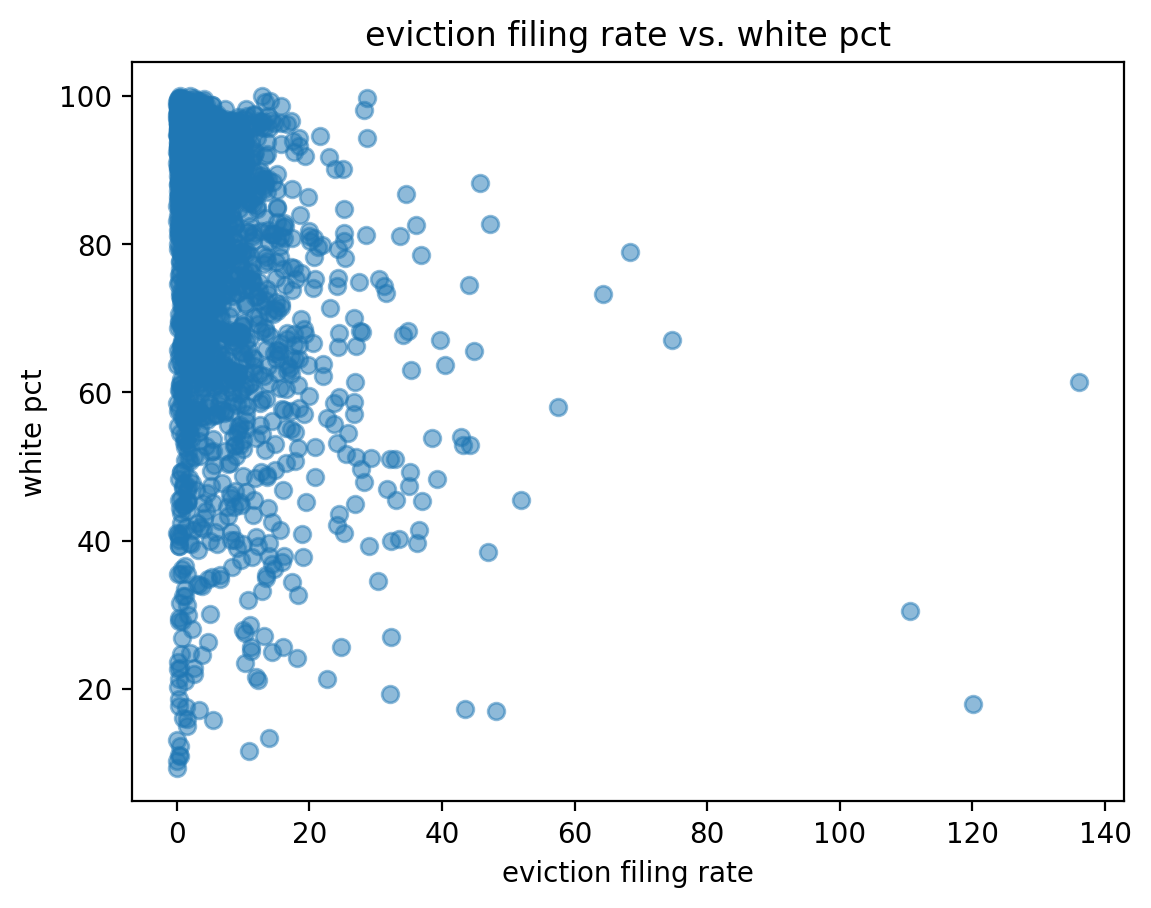

In [ ]:
# just exploring a subset of columns
for col in ["renters_pct", "median_gross_rent", "black_pct", "white_pct"]:
    plt.scatter(
        gdf_eviction_filings_demo["filing_rate"],
        gdf_eviction_filings_demo[col],
        alpha=0.5,
    )
    plt.xlabel("eviction filing rate")
    plt.ylabel(col.replace("_", " "))
    plt.title(f"eviction filing rate vs. {col.replace('_', ' ')}")
    plt.show()

## Eviction Data: NYC Open Data

The Eviction Lab provides a comprehensive resource on evictions, but it's not the only resource on evictions. We can also use local data. For example, New York City publishes an [Open Data set](https://data.cityofnewyork.us/City-Government/Evictions/6z8x-wfk4/about_data) on *executed* evictions. This is building level data on evictions going back to 2017.

Eviction data in general is challenging to obtain and often subject to specific state and local policies. For example, the New York State OCA Data Collective receives housing court filings data from the state Office of Court Administration and shares this with local organizations like the [Housing Data Coalition](https://www.housingdatanyc.org/). The OCA Data Collective includes organizations like the Right to Counsel Coalition, BetaNYC, the Association for Neighborhood and Housing Development, the University Neighborhood Housing Program, and JustFix. It is also affiliated with the Housing Data Coalition (HDC). Together, these groups help to make local, deidentified eviction *filing* data available for New York City, often to support tenant advocacy groups and to fight predatory landlords.

A helpful feature of working with local data from NYC is the use of a borough-block-lot identifier, which uniquely identifies every parcel in the city. This makes it very easy to join tabular data (i.e., eviction data) to geospatial data (i.e., parcel data), and allows us to avoid geocoding ourselves.

We'll first load a subset of [MapPLUTO](https://www.nyc.gov/content/planning/pages/resources?search=pluto#datasets), which is the New York City Department of City Planning's geospatial tax lot data. PLUTO stands for the primary land use tax output.

Note: for ease of loading the data, we'll load only a subset of parcels that we know will join to our eviction data.

In [ ]:
mppluto = gpd.read_file("mappluto_subset.gpkg")
mppluto.head()

,BBL,OwnerType,LandUse,UnitsTotal,UnitsRes,AssessLand,AssessTot,ExemptTot,YearBuilt,geometry
0,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,"MULTIPOLYGON (((981311.209 195510.668, 981240...."
1,1.000100e+09,None,05,97.0,0.0,6930000.0,30483900.0,0.0,1930.0,"MULTIPOLYGON (((980867.809 195627.081, 980872...."
2,1.000118e+09,None,04,4.0,3.0,363150.0,3464190.0,0.0,1900.0,"MULTIPOLYGON (((980911.184 195813.831, 980911...."
3,1.000160e+09,X,05,6.0,0.0,52420950.0,350676450.0,350676450.0,2009.0,"MULTIPOLYGON (((980392.176 199856.826, 980381...."
4,1.000200e+09,None,05,71.0,0.0,11340000.0,32468850.0,0.0,1983.0,"MULTIPOLYGON (((980678.427 196676.025, 980634...."


In [ ]:
mppluto.columns

Index(['BBL', 'OwnerType', 'LandUse', 'UnitsTotal', 'UnitsRes', 'AssessLand',
       'AssessTot', 'ExemptTot', 'YearBuilt', 'geometry'],
      dtype='object')

In [ ]:
mppluto["BBL"].unique().shape, mppluto["BBL"].shape

((40536,), (40536,))

Now we'll load our eviction data from NYC Open Data.

In [ ]:
df_nyc_evictions = pd.read_csv(
    "https://data.cityofnewyork.us/resource/6z8x-wfk4.csv?$limit=1000000"
)

In [ ]:
df_nyc_evictions.shape

(107319, 20)

Now we'll merge the two together. Notice: we can merge on BBL, which is might simpler than geocoding and doing a spatial join.

In [ ]:
nyc_evictions_pluto = mppluto[
    [
        "BBL",
        "OwnerType",
        "LandUse",
        "UnitsTotal",
        "UnitsRes",
        "AssessLand",
        "AssessTot",
        "ExemptTot",
        "YearBuilt",
        "geometry",
    ]
].merge(df_nyc_evictions, left_on="BBL", right_on="bbl")

In [ ]:
# create a version that's point data using centroid
nyc_evictions_pluto_centroid = nyc_evictions_pluto.copy()
nyc_evictions_pluto_centroid["geometry"] = nyc_evictions_pluto_centroid[
    "geometry"
].centroid

In [ ]:
nyc_evictions_pluto_centroid

,BBL,OwnerType,LandUse,UnitsTotal,UnitsRes,AssessLand,AssessTot,ExemptTot,YearBuilt,geometry,...,ejectment,eviction_possession,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta
0,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,POINT (981261.765 195554.133),...,Not an Ejectment,Possession,40.703611,-74.010932,1.0,1.0,9.0,1077806.0,1.000078e+09,Battery Park City-Lower Manhattan
1,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,POINT (981261.765 195554.133),...,Not an Ejectment,Possession,40.703611,-74.010932,1.0,1.0,9.0,1077806.0,1.000078e+09,Battery Park City-Lower Manhattan
2,1.000100e+09,None,05,97.0,0.0,6930000.0,30483900.0,0.0,1930.0,POINT (980936.841 195692.534),...,Not an Ejectment,Possession,40.703954,-74.011592,1.0,1.0,9.0,1000025.0,1.000100e+09,Battery Park City-Lower Manhattan
3,1.000118e+09,None,04,4.0,3.0,363150.0,3464190.0,0.0,1900.0,POINT (980899.252 195838.209),...,Not an Ejectment,Possession,40.704034,-74.012068,1.0,1.0,9.0,1000040.0,1.000118e+09,Battery Park City-Lower Manhattan
4,1.000160e+09,X,05,6.0,0.0,52420950.0,350676450.0,350676450.0,2009.0,POINT (980246.708 199670.73),...,Not an Ejectment,Possession,40.713846,-74.013812,1.0,1.0,31703.0,1087239.0,1.000160e+09,Battery Park City-Lower Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96669,5.080200e+09,None,01,2.0,2.0,9360.0,48180.0,0.0,2001.0,POINT (917315.693 127550.54),...,Not an Ejectment,Possession,40.516716,-74.240628,3.0,51.0,248.0,5129474.0,5.080200e+09,Charleston-Richmond Valley-Tottenville
96670,5.080200e+09,None,01,2.0,2.0,9360.0,48180.0,0.0,2001.0,POINT (917315.693 127550.54),...,Not an Ejectment,Possession,40.516716,-74.240628,3.0,51.0,248.0,5129474.0,5.080200e+09,Charleston-Richmond Valley-Tottenville
96671,5.080280e+09,None,01,2.0,2.0,5280.0,33660.0,0.0,2005.0,POINT (914945.422 125603.509),...,Not an Ejectment,Possession,40.511220,-74.248970,3.0,51.0,248.0,5146458.0,5.080280e+09,Charleston-Richmond Valley-Tottenville
96672,5.080280e+09,None,01,2.0,2.0,5280.0,33660.0,0.0,2005.0,POINT (914945.422 125603.509),...,Not an Ejectment,Possession,40.511220,-74.248970,3.0,51.0,248.0,5146458.0,5.080280e+09,Charleston-Richmond Valley-Tottenville


In [ ]:
building_eviction_count = (
    nyc_evictions_pluto.value_counts("BBL")
    .reset_index()
    .rename(columns={"count": "total_num_evictions"})
)
nyc_evictions_pluto = nyc_evictions_pluto.merge(building_eviction_count, on="BBL")
nyc_evictions_pluto.head()

,BBL,OwnerType,LandUse,UnitsTotal,UnitsRes,AssessLand,AssessTot,ExemptTot,YearBuilt,geometry,...,eviction_possession,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,total_num_evictions
0,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,"MULTIPOLYGON (((981311.209 195510.668, 981240....",...,Possession,40.703611,-74.010932,1.0,1.0,9.0,1077806.0,1.000078e+09,Battery Park City-Lower Manhattan,2
1,1.000078e+09,None,04,43.0,42.0,1741500.0,6970950.0,0.0,1880.0,"MULTIPOLYGON (((981311.209 195510.668, 981240....",...,Possession,40.703611,-74.010932,1.0,1.0,9.0,1077806.0,1.000078e+09,Battery Park City-Lower Manhattan,2
2,1.000100e+09,None,05,97.0,0.0,6930000.0,30483900.0,0.0,1930.0,"MULTIPOLYGON (((980867.809 195627.081, 980872....",...,Possession,40.703954,-74.011592,1.0,1.0,9.0,1000025.0,1.000100e+09,Battery Park City-Lower Manhattan,1
3,1.000118e+09,None,04,4.0,3.0,363150.0,3464190.0,0.0,1900.0,"MULTIPOLYGON (((980911.184 195813.831, 980911....",...,Possession,40.704034,-74.012068,1.0,1.0,9.0,1000040.0,1.000118e+09,Battery Park City-Lower Manhattan,1
4,1.000160e+09,X,05,6.0,0.0,52420950.0,350676450.0,350676450.0,2009.0,"MULTIPOLYGON (((980392.176 199856.826, 980381....",...,Possession,40.713846,-74.013812,1.0,1.0,31703.0,1087239.0,1.000160e+09,Battery Park City-Lower Manhattan,1


In [ ]:
nyc_evictions_pluto[["UnitsRes", "total_num_evictions"]]

,UnitsRes,total_num_evictions
0,42.0,2
1,42.0,2
2,0.0,1
3,3.0,1
4,0.0,1
...,...,...
96669,2.0,2
96670,2.0,2
96671,2.0,2
96672,2.0,2


In [ ]:
# let's compute a building level rate
nyc_evictions_pluto["eviction_rate_bldg"] = (
    nyc_evictions_pluto["total_num_evictions"] / nyc_evictions_pluto["UnitsTotal"]
)
nyc_evictions_pluto["eviction_rate_bldg"] = np.where(
    nyc_evictions_pluto["UnitsTotal"] == 0,
    np.nan,
    nyc_evictions_pluto["eviction_rate_bldg"],
)
nyc_evictions_pluto["eviction_rate_bldg"].describe()

,eviction_rate_bldg
count,96424.000000
mean,0.455129
std,2.339168
min,0.000103
25%,0.063145
50%,0.148148
75%,0.368421
max,69.000000


Notice, there are some cases where the total number of units is 0, and so our building eviction rate is missing. It's possible that the number of building units changed over time, or the data has been collected incorrectly. We'll just set these cases to missing, but it's worth investigating for a more in depth analysis.

In [ ]:
print(nyc_evictions_pluto["eviction_rate_bldg"].isna().mean())
nyc_evictions_pluto[nyc_evictions_pluto["eviction_rate_bldg"].isna()]

0.002586010716428409


,BBL,OwnerType,LandUse,UnitsTotal,UnitsRes,AssessLand,AssessTot,ExemptTot,YearBuilt,geometry,...,latitude,longitude,community_board,council_district,census_tract,bin,bbl,nta,total_num_evictions,eviction_rate_bldg
238,1.000240e+09,P,05,0.0,0.0,20160000.0,96930000.0,0.0,1961.0,"MULTIPOLYGON (((980921.36 196349.247, 981044.0...",...,40.705351,-74.011502,1.0,1.0,9.0,1000817.0,1.000240e+09,Battery Park City-Lower Manhattan,1,NaN
414,1.002000e+09,None,05,0.0,0.0,684000.0,1585800.0,0.0,1951.0,"MULTIPOLYGON (((984734.775 200383.457, 984757....",...,40.716537,-73.997947,3.0,1.0,29.0,1002391.0,1.002000e+09,Chinatown,1,NaN
437,1.001620e+09,None,11,0.0,0.0,445050.0,445050.0,0.0,0.0,"MULTIPOLYGON (((984674.558 199465.527, 984698....",...,40.713693,-73.998092,3.0,1.0,29.0,1001708.0,1.001620e+09,Chinatown,1,NaN
1649,1.006320e+09,None,11,0.0,0.0,596250.0,596250.0,0.0,0.0,"MULTIPOLYGON (((981990.872 206807.111, 981988....",...,40.734152,-74.008476,2.0,3.0,75.0,1000000.0,1.006320e+09,West Village,1,NaN
2013,1.004850e+09,None,10,0.0,0.0,192600.0,192600.0,0.0,0.0,"MULTIPOLYGON (((984203.404 202638.627, 984190....",...,40.722808,-74.000144,2.0,1.0,49.0,1000000.0,1.004850e+09,SoHo-TriBeCa-Civic Center-Little Italy,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95750,5.001950e+09,None,10,0.0,0.0,50400.0,50400.0,0.0,0.0,"MULTIPOLYGON (((950885.543 171291.553, 950783....",...,40.637050,-74.120695,1.0,49.0,13302.0,5000000.0,5.001950e+09,West New Brighton-New Brighton-St. George,1,NaN
95799,5.002290e+09,None,11,0.0,0.0,80550.0,80550.0,0.0,0.0,"MULTIPOLYGON (((950006.271 168601.619, 949983....",...,40.629502,-74.123401,1.0,49.0,141.0,5000000.0,5.002290e+09,West New Brighton-New Brighton-St. George,1,NaN
95991,5.008780e+09,None,None,0.0,0.0,117000.0,219150.0,0.0,0.0,"MULTIPOLYGON (((954219.502 158356.556, 954192....",...,40.601666,-74.108682,2.0,50.0,177.0,5154780.0,5.008780e+09,Todt Hill-Emerson Hill-Heartland Village-Light...,1,NaN
96039,5.011270e+09,None,10,0.0,0.0,11760.0,13680.0,0.0,0.0,"MULTIPOLYGON (((943734.599 169698.832, 943727....",...,40.632511,-74.146476,1.0,49.0,213.0,5026205.0,5.011270e+09,Port Richmond,1,NaN


We'll subset to nonmissing eviction rates.

In [ ]:
nyc_evictions_pluto = nyc_evictions_pluto[
    nyc_evictions_pluto["eviction_rate_bldg"].notna()
]

In [ ]:
nyc_evictions_pluto["eviction_rate_bldg"].min(), nyc_evictions_pluto[
    "eviction_rate_bldg"
].max(), nyc_evictions_pluto["eviction_rate_bldg"].quantile(0.95)

(0.0001034233116144379, 69.0, np.float64(1.3333333333333333))

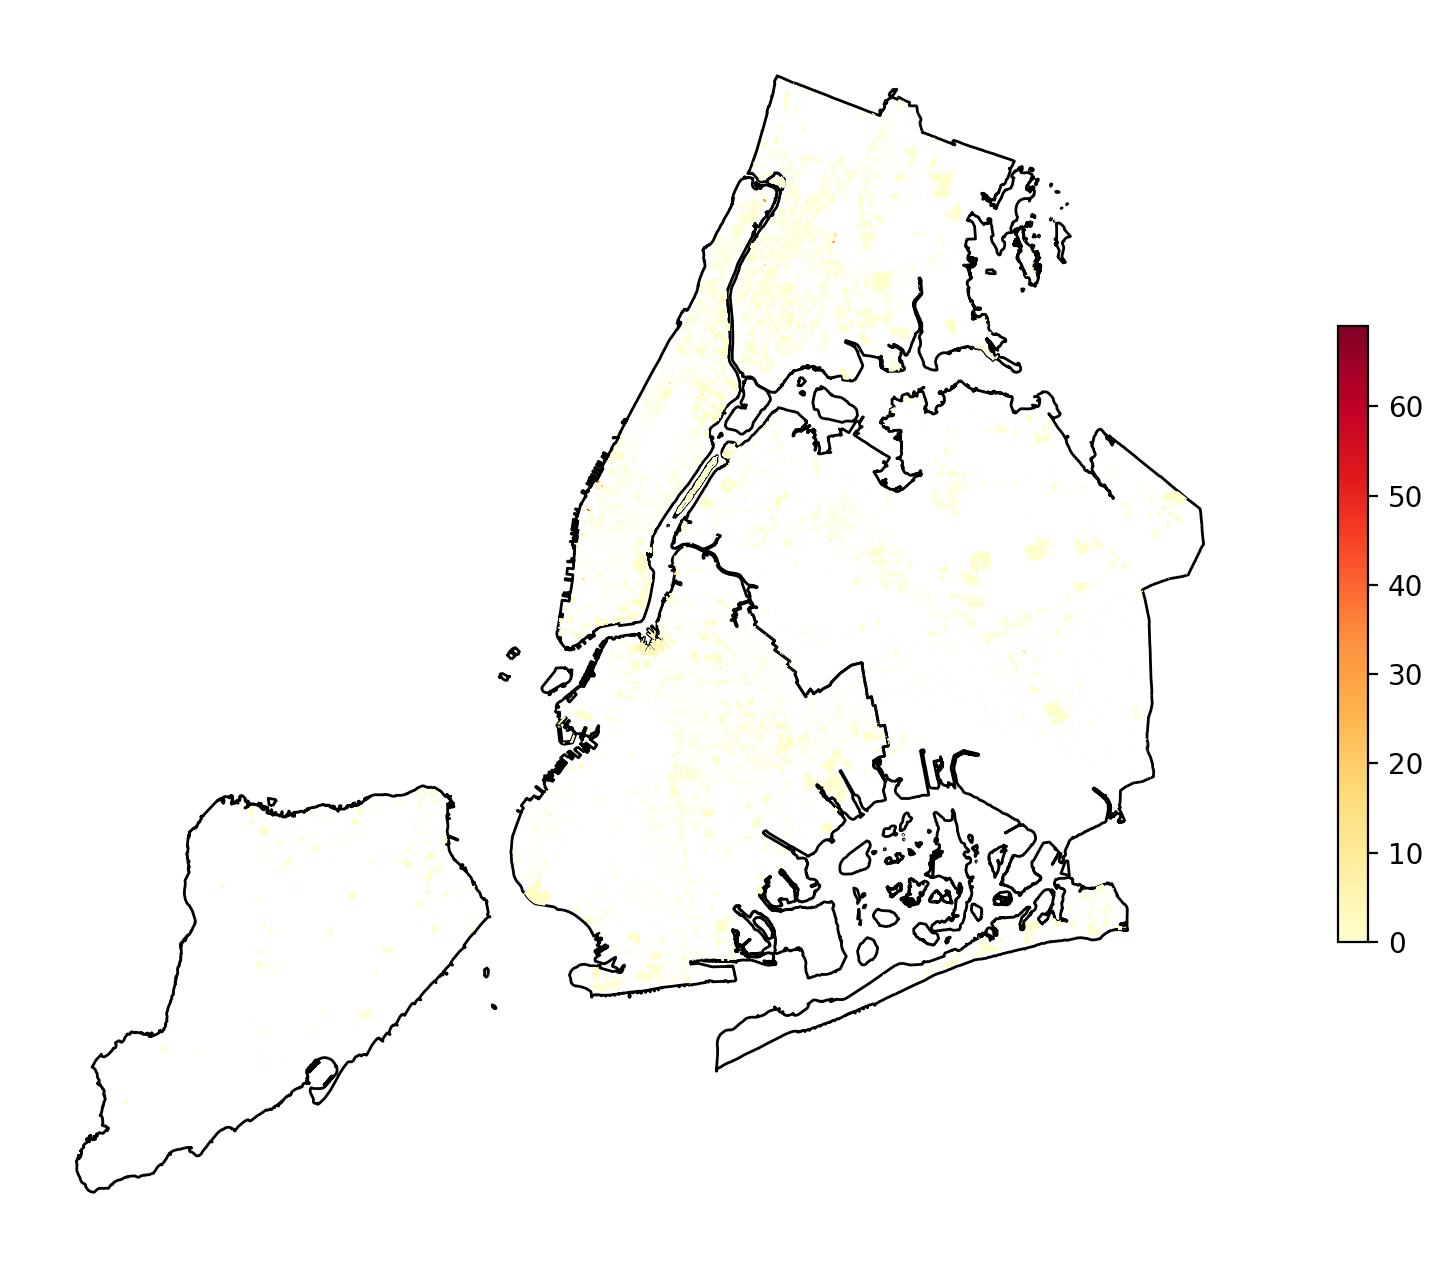

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
boros = gpd.read_file(
    "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Borough_Boundary/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=pgeojson"
).to_crs(2263)
boros.plot(ax=ax, facecolor="none")
nyc_evictions_pluto.plot(
    ax=ax,
    column="eviction_rate_bldg",
    vmin=0,
    legend=True,
    cmap="YlOrRd",
    legend_kwds={"shrink": 0.4},
)
ax.set_axis_off()

Let's try visualizing this better. We'll drop extreme outliers, and we'll change the size of points based on the eviction rate. We'll also use the building centroid.

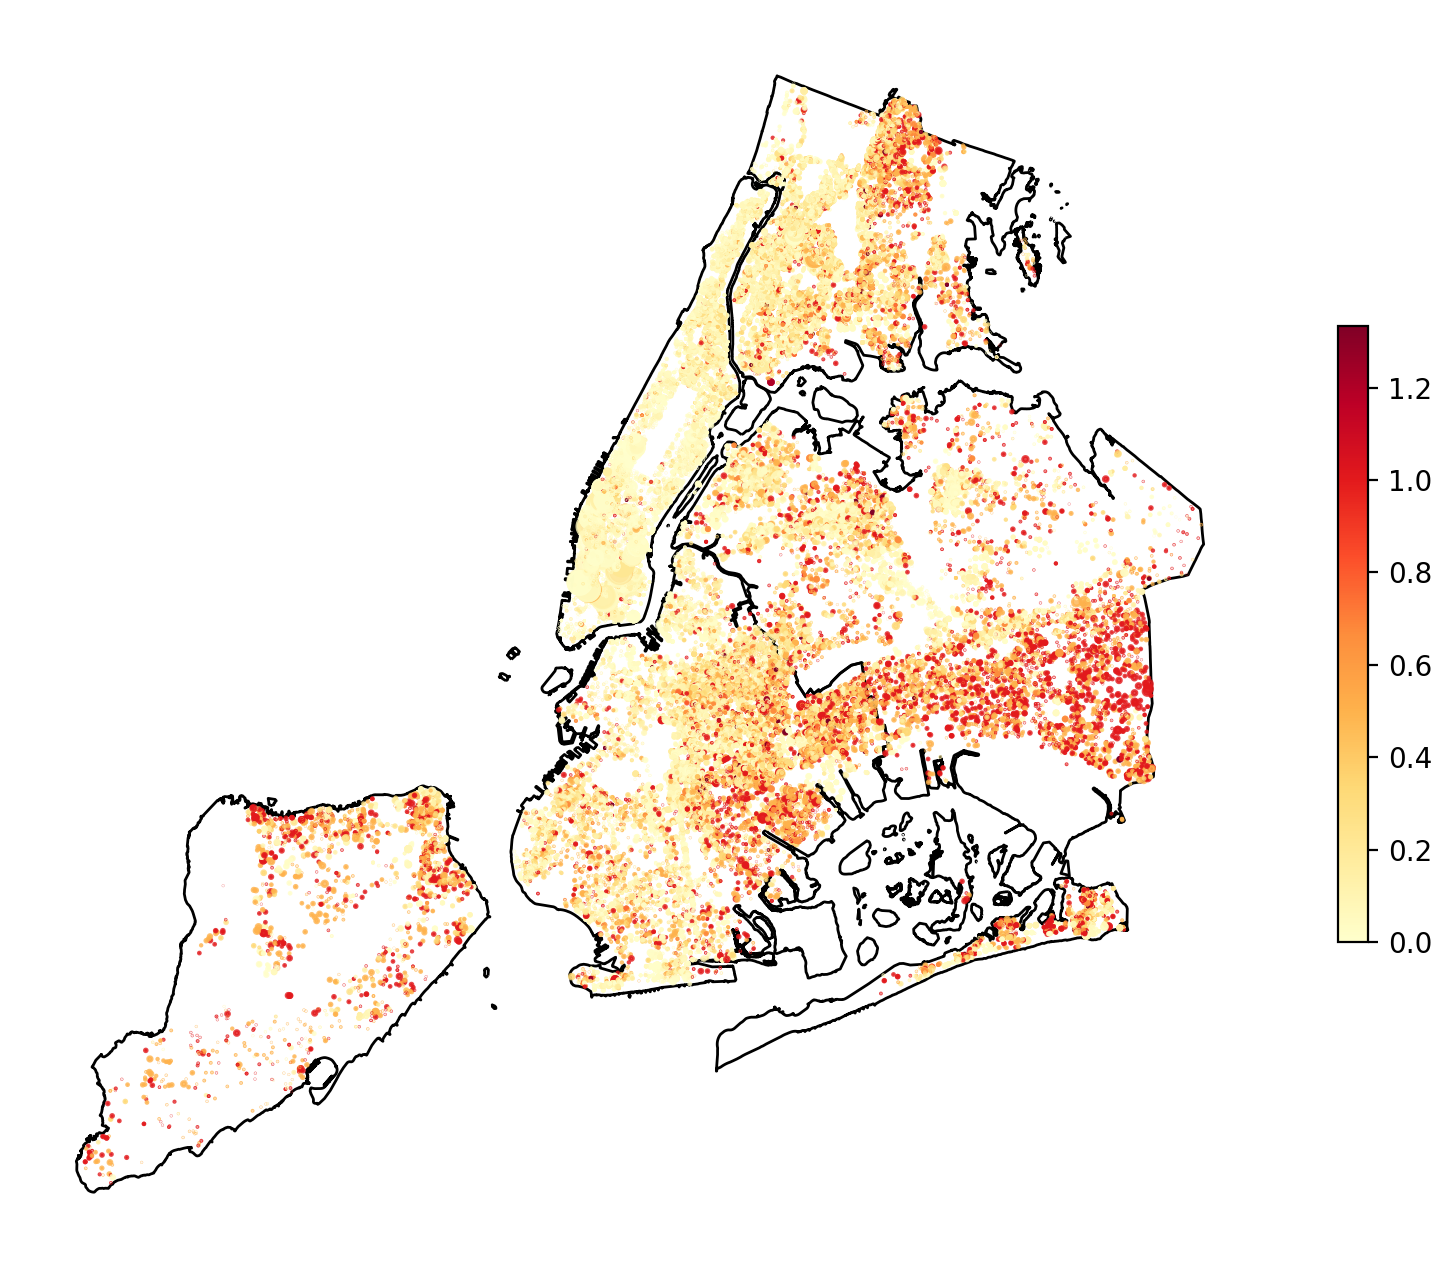

In [ ]:
nyc_evictions_pluto["geometry"] = nyc_evictions_pluto["geometry"].centroid

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
boros.plot(ax=ax, facecolor="none")
nyc_evictions_pluto[
    nyc_evictions_pluto["eviction_rate_bldg"]
    <= nyc_evictions_pluto["eviction_rate_bldg"].quantile(0.95)
].plot(
    ax=ax,
    column="eviction_rate_bldg",
    markersize=nyc_evictions_pluto["eviction_rate_bldg"],
    vmin=0,
    alpha=0.8,
    legend=True,
    cmap="YlOrRd",
    legend_kwds={"shrink": 0.4},
)
ax.set_axis_off()

We can also make a heatmap using Folium.

In [ ]:
map = folium.Map(location=[40.7, -73.97], tiles="Cartodb dark_matter", zoom_start=10)
heat_data = [
    [point.xy[1][0], point.xy[0][0]]
    for point in nyc_evictions_pluto_centroid.to_crs(4326).geometry
]

folium.plugins.HeatMap(heat_data, radius=20, blur=20, min_opacity=0.2).add_to(
    map,
)
map